# Customer Churn & Retention Strategy Analysis

## Objective
The objective of this project is to analyze customer demographics, service usage, and billing information
to identify the key drivers of customer churn and propose data-driven retention strategies for a
telecommunications company.

## Business Questions
- Which customers are most likely to churn?
- What factors are most strongly associated with churn?
- Where should the company focus retention efforts to minimize revenue loss?

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [11]:
from google.colab import files
uploaded = files.upload()

Saving telecom.csv to telecom (1).csv


In [12]:
df = pd.read_csv('telecom.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)



In [16]:
df['Churn'].unique()
df['Churn'] = df['Churn'].str.strip()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [18]:
df['Churn'].value_counts(dropna=False)
df[['TotalCharges', 'Churn']].head()


,TotalCharges,Churn
0,29.85,0
1,1889.50,0
2,108.15,1
3,1840.75,0
4,151.65,1


In [19]:
selected_cols = [
    'Churn',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'PaymentMethod',
    'PaperlessBilling',
    'InternetService',
    'TechSupport',
    'OnlineSecurity',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]

df = df[selected_cols]
df.head()


,Churn,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,InternetService,TechSupport,OnlineSecurity,SeniorCitizen,Partner,Dependents
0,0,1,29.85,29.85,Month-to-month,Electronic check,Yes,DSL,No,No,0,Yes,No
1,0,34,56.95,1889.50,One year,Mailed check,No,DSL,No,Yes,0,No,No
2,1,2,53.85,108.15,Month-to-month,Mailed check,Yes,DSL,No,Yes,0,No,No
3,0,45,42.30,1840.75,One year,Bank transfer (automatic),No,DSL,Yes,Yes,0,No,No
4,1,2,70.70,151.65,Month-to-month,Electronic check,Yes,Fiber optic,No,No,0,No,No


## Business KPIs

To understand customer churn from a business perspective, the following key performance indicators (KPIs)
are calculated:
- Churn Rate
- Average Monthly Revenue
- Average Customer Tenure
- Revenue at Risk from Churned Customers


In [20]:
churn_rate = df['Churn'].mean()
print(f"Churn Rate: {churn_rate:.2%}")


Churn Rate: 26.58%


In [21]:
avg_monthly_revenue = df['MonthlyCharges'].mean()
print(f"Average Monthly Revenue: ${avg_monthly_revenue:.2f}")


Average Monthly Revenue: $64.80


In [22]:
avg_tenure = df['tenure'].mean()
print(f"Average Tenure: {avg_tenure:.1f} months")


Average Tenure: 32.4 months


In [23]:
revenue_at_risk = df.loc[df['Churn'] == 1, 'MonthlyCharges'].sum()
print(f"Revenue at Risk from Churned Customers: ${revenue_at_risk:.2f}")


Revenue at Risk from Churned Customers: $139130.85


In [24]:
kpis = pd.DataFrame({
    'KPI': ['Churn Rate', 'Average Monthly Revenue', 'Average Tenure', 'Revenue at Risk'],
    'Value': [f"{churn_rate:.2%}", f"${avg_monthly_revenue:.2f}", f"{avg_tenure:.1f} months", f"${revenue_at_risk:.2f}"]
})
kpis


,KPI,Value
0,Churn Rate,26.58%
1,Average Monthly Revenue,$64.80
2,Average Tenure,32.4 months
3,Revenue at Risk,$139130.85


**Insights from KPIs:**
- 26.6% of customers are leaving — a significant churn rate.
- Revenue at risk is over $139k per month — retention could have major financial impact.
- Shorter-tenure customers and month-to-month contracts are likely driving much of the churn.


# Exploratory Data Analysis (EDA)

In this section, we explore key factors associated with customer churn.  
The goal is to identify patterns that inform retention strategies.


## Churn Rate by Contract Type

This bar chart shows how churn varies across contract types.  
Insight: Month-to-month customers have the highest churn, suggesting that retention efforts should prioritize this group.


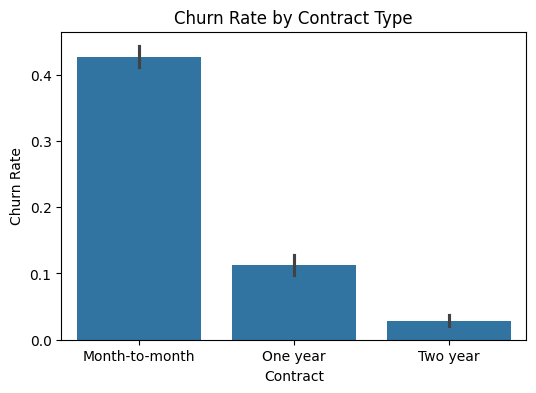

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Contract', y='Churn')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.show()


## Tenure Distribution by Churn Status

This boxplot shows the distribution of customer tenure for churned vs retained customers.  
Insight: Customers who churn generally have shorter tenure, highlighting early-stage churn risk.


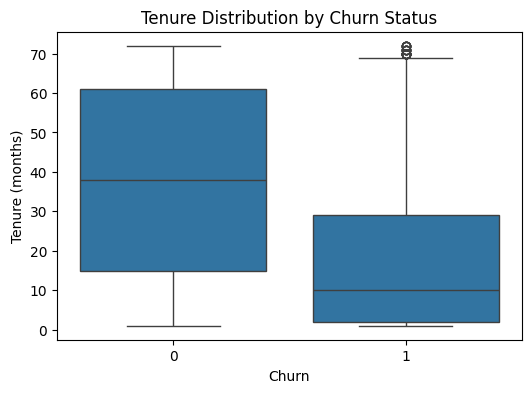

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')
plt.title('Tenure Distribution by Churn Status')
plt.show()


## Monthly Charges vs Churn

This boxplot compares monthly charges for churned vs retained customers.  
Insight: Customers with higher monthly charges may be more likely to churn, indicating potential pricing or value perception issues.


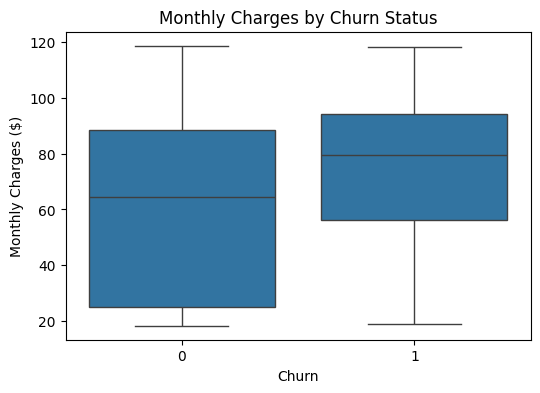

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.title('Monthly Charges by Churn Status')
plt.show()


## Churn Rate by Tech Support Subscription

This bar chart shows how churn varies by whether a customer has tech support.  
Insight: Customers without tech support churn more frequently, suggesting targeted support could reduce churn.


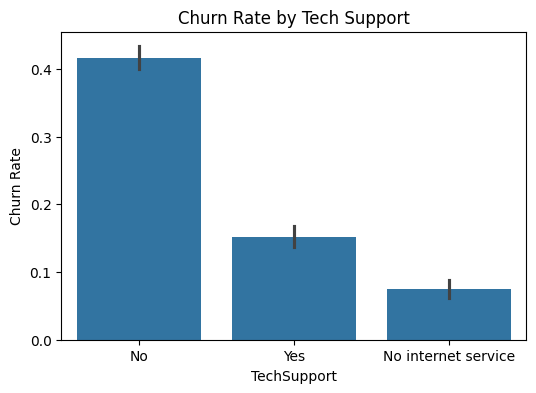

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='TechSupport', y='Churn')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Tech Support')
plt.show()


# Customer Segmentation: Value × Churn Risk

We segment customers into four groups based on **MonthlyCharges (value)** and **Churn (risk)**:

1. **High Value, High Risk** → Most important to retain
2. **High Value, Low Risk** → Already valuable, low effort
3. **Low Value, High Risk** → Less priority
4. **Low Value, Low Risk** → Low priority, optional interventions


In [29]:
# Define high vs low value using median MonthlyCharges
median_value = df['MonthlyCharges'].median()
df['ValueSegment'] = np.where(df['MonthlyCharges'] >= median_value, 'High Value', 'Low Value')

# Define risk based on churn
df['RiskSegment'] = np.where(df['Churn'] == 1, 'High Risk', 'Low Risk')

# Combine for 4 segments
df['Segment'] = df['ValueSegment'] + ' & ' + df['RiskSegment']
df['Segment'].value_counts()


,count
Segment,
Low Value & Low Risk,2879
High Value & Low Risk,2284
High Value & High Risk,1238
Low Value & High Risk,631


## Customer Segment Distribution Analysis

The largest group is **Low Value & Low Risk**, which is expected: most customers pay below the median and are retained.  

The smallest groups are **High Value & High Risk** and **Low Value & High Risk**.  
- These customers are more likely to churn, but the "High Value & High Risk" segment is the most critical to target because each lost customer impacts revenue significantly.  

Recommendation: Focus retention resources on **High Value & High Risk** customers for maximum financial impact.


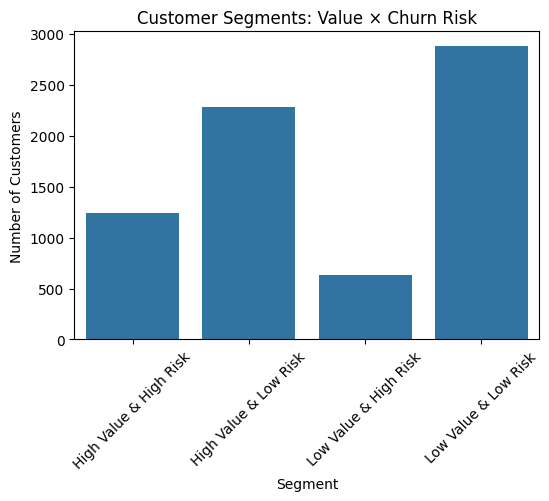

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Segment', order=[
    'High Value & High Risk',
    'High Value & Low Risk',
    'Low Value & High Risk',
    'Low Value & Low Risk'
])
plt.title('Customer Segments: Value × Churn Risk')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()


# Predicting Customer Churn

In addition to descriptive analysis, I build a simple predictive model to identify customers who are likely to churn.  
This helps the company **proactively retain high-risk customers**.


## Features and Target

- **Target variable:** Churn (0 = retained, 1 = churned)
- **Features:** Demographics, account info, and service subscriptions
- **Encoding:** Categorical variables are converted to numeric using one-hot encoding
- **Train/Test Split:** 70% training, 30% testing


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop columns not needed for modeling
X = df.drop(columns=['Churn', 'Segment', 'ValueSegment', 'RiskSegment'])
y = df['Churn']

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Optional: scale numeric features
scaler = StandardScaler()
X[['tenure','MonthlyCharges','TotalCharges']] = scaler.fit_transform(X[['tenure','MonthlyCharges','TotalCharges']])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## Model Choice

I use **Logistic Regression**, a simple and interpretable model suitable for predicting churn probabilities.  



In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {accuracy:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')


Accuracy: 0.79
ROC-AUC Score: 0.83


## Model Insights

## Predictive Model Performance

- **Accuracy:** 79% — the model correctly predicts customer churn 79% of the time.
- **ROC-AUC Score:** 0.83 — the model reliably distinguishes between churned and retained customers.
- **Interpretation:** The model can be used to identify high-risk customers for targeted retention strategies, translating insights into actionable business decisions.



# Key Insights & Recommendations

This section summarizes the main findings from the analysis and provides actionable recommendations for the company.


## Insights

1. **Overall Churn:** 26.6% of customers are leaving, which represents a revenue at risk of $139,130.85 per month.
2. **Contract Impact:** Month-to-month customers have the highest churn, highlighting the importance of incentivizing longer-term contracts.
3. **Tenure:** Customers who churn tend to have shorter tenure, indicating early-stage churn risk.
4. **Monthly Charges:** Higher-paying customers may have slightly higher churn risk — these are high-value customers worth targeting.
5. **Service Usage:** Customers without tech support are more likely to churn, suggesting targeted interventions could be effective.
6. **Customer Segments:** The "High Value & High Risk" segment is the most critical group for retention efforts, while "Low Value & Low Risk" represents the largest, stable base.


## Recommendations

1. **Retention Programs for High-Value Customers:**
   - Target "High Value & High Risk" customers with incentives, priority support, or personalized offers to reduce churn.

2. **Contract Incentives:**
   - Encourage month-to-month customers to switch to 1- or 2-year contracts to lower churn risk.

3. **Early Intervention:**
   - Monitor and support customers with tenure < 6 months, as they are more likely to churn early.

4. **Service Improvements:**
   - Promote tech support subscriptions, especially to customers showing early churn indicators.

5. **Segment Tracking:**
   - Continuously monitor the value × churn segments over time to measure effectiveness of retention strategies.
